# Digital Earth Australia Mosaic Metadata Command Line Interfaces (CLI)

This notebook demonstrates how to call the DEA Mosaic Metadata workflows via Command Line Interface utilities. 
This allows you to generate ODC STAC and YAML metadata and thumbnails for DEA mosaic products, using a single line of code.

## Getting started
Set working directory to top level of repo to ensure links work correctly:



In [1]:
cd ../..

/home/jovyan/dev/prod/dea-intertidal-multi/dea-intertidal


Install the latest version of `dea-intertidal`:


In [ ]:
%pip install -e .

In [2]:
%load_ext autoreload
%autoreload 2

import rasterio
print(rasterio.__gdal_version__)
import datacube
print(datacube.__version__)


3.10.0
1.9.10


## Setup


### Set analysis parameters
Sets the required parameters year, product and version. 

In [2]:
year = "2024"
product = "ga_s2ls_intertidal_cyear_3"
version = "2-1-0"

## DEA Mosaic Metadata CLI
This CLI allows you to generate the following DEA Metadata outputs with a single command line call:
* **ODC STAC metadata**
* **ODC YAML metdata**
* **thumbnail**

Running `--help` shows all the CLI parameters that can be used to customise the analysis:

In [3]:
!python -m intertidal.metadata_generator generate --help

Usage: python -m intertidal.metadata_generator generate [OPTIONS]

  Generate ODC YAML and STAC JSON metadata for a product.

  Example:

      mosaic-metadata generate --year 2022 \         --product
      ga_s2_coastalecosystems_cyear_3_v1 \         --version 1-0-0

  Product family is auto-detected from product name, or specify explicitly:

      mosaic-metadata generate --year 2022 \         --product
      ga_s2_coastalecosystems_cyear_3_v1 \         --version 1-0-0 \
      --product-family coastalecosystems

Options:
  --year TEXT                     Year of the product (e.g., 2022)  [required]
  --product TEXT                  Product name (e.g.,
                                  ga_s2_coastalecosystems_cyear_3_v1)
                                  [required]
  --version TEXT                  Product version (e.g., 1-0-0)  [required]
  --product-family TEXT           Product family (auto-detected from product
                                  name if not specified: intertidal,
 

Run DEA Mosaic Metadata CLI for a single epoch. This will generate DEA Mosaic Metadata for a single year for a single product:

In [5]:
%%time

!python -m intertidal.metadata_generator generate \
    --year {year} \
    --product {product} \
    --version {version} \
    --verbose \
    --multipolygon

Auto-detected product family: intertidal
Configuration:
  Year: 2024
  Product: ga_s2ls_intertidal_cyear_3
  Title: ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y
  S3 folder: s3://dea-public-data-dev/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/

Extracting lineage from tile STAC files...
  Tile directory: dea-public-data-dev/derivative
  Product: ga_s2ls_intertidal_cyear_3
  Version: 2-1-0
  Year: 2024
Searching for STAC files: dea-public-data-dev/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/x*/y*/2024--P1Y/*.stac-item.json
Mosaic naming convention: dea_c3
Tile naming convention: dea_c3
Found 1330 STAC files for ga_s2ls_intertidal_cyear_3

Processing STAC metadata files...
  Processed 100/1330 files...
  Processed 200/1330 files...
  Processed 300/1330 files...
  Processed 400/1330 files...
  Processed 500/1330 files...
  Processed 600/1330 files...
  Processed 700/1330 files...
  Processed 800/1330 files...
  Processed 900/1330 files...
  Processed 1000/1330

### Validation

Use the DEA Mosaic Metadata CLI to validate a local metadata file:

In [6]:
file_yaml = "metadata/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.odc-metadata.yaml"

!python -m intertidal.metadata_generator validate {file_yaml}

✓ metadata/ga_s2ls_intertidal_cyear_3.odc-product.yaml
✓ metadata/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.odc-metadata.yaml

valid: 2 paths


Use the DEA Mosaic Metadata CLI to validate a metadata file on S3:

In [7]:
file_yaml = "https://data.dev.dea.ga.gov.au/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.odc-metadata.yaml"

!python -m intertidal.metadata_generator validate {file_yaml}

✓ metadata/ga_s2ls_intertidal_cyear_3.odc-product.yaml
✓ file:///tmp/tmpd1j0drf7.odc-metadata.yaml

valid: 2 paths


### Previewing paths
Use DEA Mosaic Metadata CLI to show the paths it will use:

In [8]:
!python -m intertidal.metadata_generator show-paths \
    --year 2024 \
    --product ga_s2ls_intertidal_cyear_3 \
    --version 2-1-0 \
    --prod

Product Configuration:
Title: ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y

S3 Paths:
  Folder: s3://dea-public-data/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/
  STAC JSON: s3://dea-public-data/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.stac-item.json
  ODC YAML: s3://dea-public-data/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.odc-metadata.yaml
  Thumbnail: s3://dea-public-data/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y//ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y-thumbnail.jpg

Local Paths:
  STAC JSON: ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.stac-item.json
  ODC YAML: ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.odc-metadata.yaml

Accessory Files:
  Processor Info: ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.proc-info.yaml
  Tile Lineage: ga_s2ls_intertidal_cyear_3_mosaic_2

### Run DEA Mosaic Metadata for Tidal Composites for a single epoch
This will generate metadata for DEA Intertidal Composites mosaics:

In [9]:
%%time
year = "2024"
product = "ga_s2_tidal_composites_cyear_3"
version = "1-1-0"

# Run DEA Mosaic Metadata CLI for a single epoch.
# This will generate DEA Mosaic Metadata for a single year for a single product
!python -m intertidal.metadata_generator generate  \
    --year {year} \
    --product {product} \
    --version {version} \
    --verbose \
    --multipolygon

Auto-detected product family: tidal_composites
Configuration:
  Year: 2024
  Product: ga_s2_tidal_composites_cyear_3
  Title: ga_s2_tidal_composites_cyear_3_mosaic_2024--P1Y
  S3 folder: s3://dea-public-data-dev/derivative/ga_s2_tidal_composites_cyear_3/1-1-0/continental_mosaics/2024--P1Y/

Extracting lineage from tile STAC files...
  Tile directory: dea-public-data-dev/derivative
  Product: ga_s2_tidal_composites_cyear_3
  Version: 1-1-0
  Year: 2024
Searching for STAC files: dea-public-data-dev/derivative/ga_s2_tidal_composites_cyear_3/1-1-0/x*/y*/2024--P1Y/*.stac-item.json
Mosaic naming convention: dea_c3
Tile naming convention: dea_c3
Found 1443 STAC files for ga_s2_tidal_composites_cyear_3

Processing STAC metadata files...
  Processed 100/1443 files...
  Processed 200/1443 files...
  Processed 300/1443 files...
  Processed 400/1443 files...
  Processed 500/1443 files...
  Processed 600/1443 files...
  Processed 700/1443 files...
  Processed 800/1443 files...
  Processed 900/1443 

### Run DEA Mosaic Metadata for Coastal Ecosystems for a single epoch
This will generate metadata for DEA Coastal Ecosystems mosaics:

In [11]:
# %%time
# year = "2021"
# product = "ga_s2_coastalecosystems_cyear_3_v1"
# version = "1-0-0"

# # Run DEA Mosaic Metadata CLI for a single epoch.
# # This will generate DEA Mosaic Metadata for a single year for a single product
# !python -m intertidal.metadata_generator generate  \
#     --year {year} \
#     --product {product} \
#     --version {version} \
#     --prod \
#     --naming-conventions dea \
#     --tile-dir dea-public-data-dev/derivative/dea_coastalecosystems \
#     --verbose

## Test loading data via `odc-stac`

DEA Tidal Composites:

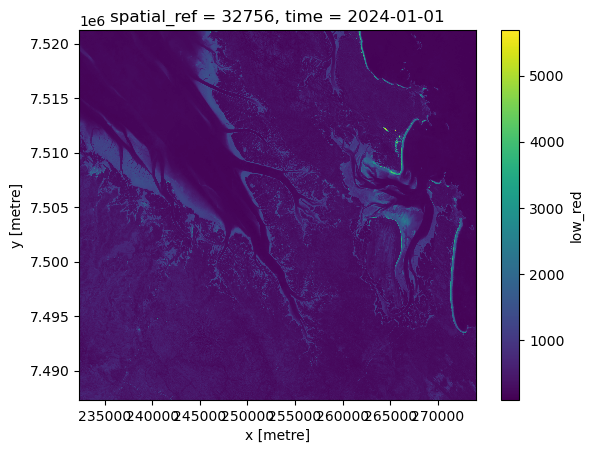

In [12]:
from pystac import Item
import odc.stac
import rasterio
import odc.geo.xr

# Build a query with the parameters above
geometry = [150.4, -22.4, 150.8, -22.7]
# path = "https://dea-public-data-dev.s3-ap-southeast-2.amazonaws.com/derivative/ga_s2_tidal_composites_cyear_3/1-1-0/continental_mosaics/2024--P1Y/ga_s2_tidal_composites_cyear_3_2024--P1Y_final.stac-item.json"
path = "metadata/ga_s2_tidal_composites_cyear_3/1-1-0/continental_mosaics/2024--P1Y/ga_s2_tidal_composites_cyear_3_mosaic_2024--P1Y.stac-item.json"

items = [Item.from_file(path)]

ds = odc.stac.load(
    items,
    bands=["low_red"],
    crs="utm",
    resolution=10,
    bbox=geometry,
)

ds.low_red.plot()

DEA Intertidal:

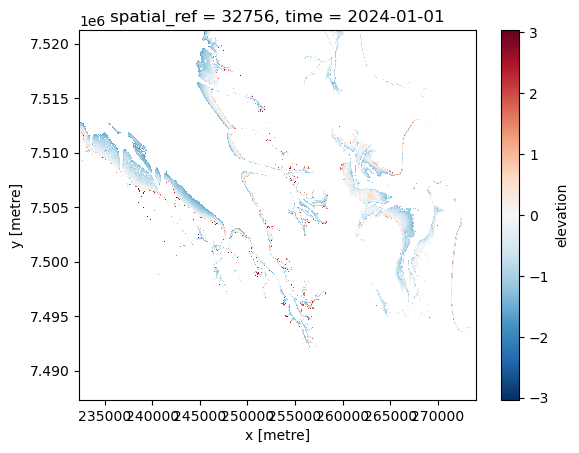

In [13]:
from pystac import Item
import odc.stac
import rasterio
import odc.geo.xr

# Build a query with the parameters above
geometry = [150.4, -22.4, 150.8, -22.7]
# path = "https://data.dev.dea.ga.gov.au/derivative/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.stac-item.json"
path = 'metadata/ga_s2ls_intertidal_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2ls_intertidal_cyear_3_mosaic_2024--P1Y.stac-item.json'

items = [Item.from_file(path)]
ds = odc.stac.load(
    items,
    bands=["elevation"],
    crs="utm",
    resolution=10,
    bbox=geometry,
)

ds.elevation.plot()

DEA Coastal Ecosystems:

In [14]:
from pystac import Item
import odc.stac
import rasterio
import odc.geo.xr

# Build a query with the parameters above
geometry = [150.4, -22.4, 150.8, -22.7]
path = "https://data.dea.ga.gov.au/derivative/ga_s2_coastalecosystems_cyear_3_v1/AU/2021--P1Y/ga_s2_coastalecosystems_cyear_3_v1-0-0_AU_2021--P1Y_final.stac-item.json"
path = "metadata/ga_s2_coastalecosystems_cyear_3_v1/AU/2021--P1Y/ga_s2_coastalecosystems_cyear_3_v1-0-0_AU_2021--P1Y_final.stac-item.json"
# path = 'metadata/ga_s2_tidal_composites_cyear_3/2-1-0/continental_mosaics/2024--P1Y/ga_s2_tidal_composites_cyear_3_mosaic_2024--P1Y.stac-item.json'
# path = '../..metadata/ga_s2_coastalecosystems_cyear_3_v1-0-0_AU_2022--P1Y_final.stac-item.json'

items = [Item.from_file(path)]
ds = odc.stac.load(
    items,
    bands=[
        "classification",
        # "mangrove_prob",
        # "saltmarsh_prob",
        # "saltflat_prob",
        # "seagrass_prob",
        # "qa_count_clear",
        # "qa_coastal_connectivity",
    ],
    crs="utm",
    resolution=10,
    # groupby="solar_day",
    bbox=geometry,
)

ds.classification.plot()

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/Robbi/dea-intertidal/metadata/ga_s2_coastalecosystems_cyear_3_v1/AU/2021--P1Y/ga_s2_coastalecosystems_cyear_3_v1-0-0_AU_2021--P1Y_final.stac-item.json'